<a href="https://colab.research.google.com/github/ruilili3-cell/cs5494_tutorial/blob/main/cs5494_tutorial_4_FVSBN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 4: From Independent Pixels to FVSBN

A generative model learns a probability distribution from observed data and uses it to generate new samples. In this tutorial, we begin with a very simple model for binarized MNIST images.

## 1. Setup

We use binarized MNIST images. Each image contains $28 \times 28 = 784$ pixels, and each pixel is represented as either 0 (black) or 1 (white).

In [ ]:
# Import the tools used for data loading, probability calculations, and visualization.
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets


# Display a collection of binary images in a grid.
def show_images(images, title, columns=8):
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(1.5 * columns, 1.5 * rows))
    axes = np.asarray(axes).reshape(-1)

    for ax, image in zip(axes, images):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Load MNIST and convert each grayscale pixel into a binary value.
train_dataset = datasets.MNIST(root="./data", train=True, download=True)
train_images = train_dataset.data
binary_train_images = (train_images >= 128).float()

print("Number of training images:", len(binary_train_images))
print("Image shape:", tuple(binary_train_images.shape[1:]))
print("Possible pixel values:", torch.unique(binary_train_images).tolist())

Number of training images: 60000
Image shape: (28, 28)
Possible pixel values: [0.0, 1.0]


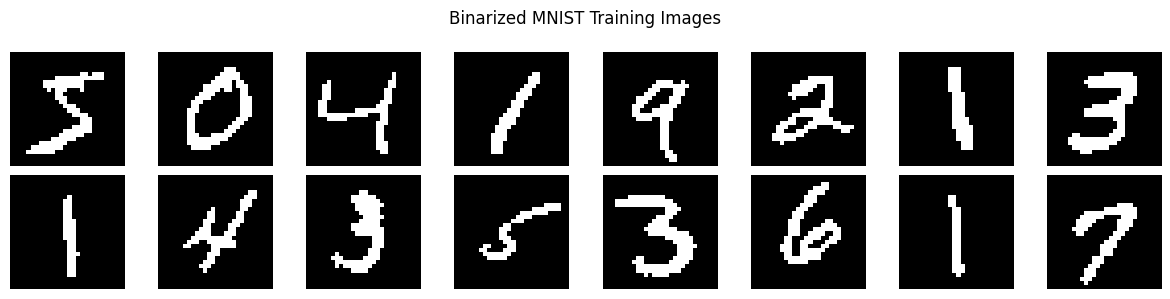

In [ ]:
# Inspect several examples from the training data.
show_images(binary_train_images[:16], "Binarized MNIST Training Images")

## 2. A Simple Generative Model

Let an image be $x=(x_1,\ldots,x_{784})$, where each $x_i \in \{0,1\}$ represents one pixel. Our goal is to learn a distribution $p(x)$ and then generate a new image by sampling $x \sim p(x)$.

We begin with the simplest possible assumption: **every pixel is independent of every other pixel**.

$$p(x)=\prod_{i=1}^{784}p(x_i)$$

Each pixel follows a Bernoulli distribution:

$$p(x_i=1)=\mu_i$$

The parameter $\mu_i$ describes how often pixel $i$ is white in the training data.

### Estimate the Pixel Probabilities

For a Bernoulli variable, the maximum-likelihood estimate of $\mu_i$ is simply the average value of pixel $i$ across the training set.

In [ ]:
# Estimate one probability for each of the 784 pixel positions.
pixel_probs = binary_train_images.mean(dim=0)

print("Probability map shape:", tuple(pixel_probs.shape))
print("Minimum probability:", pixel_probs.min().item())
print("Maximum probability:", pixel_probs.max().item())

Probability map shape: (28, 28)
Minimum probability: 0.0
Maximum probability: 0.5630833506584167


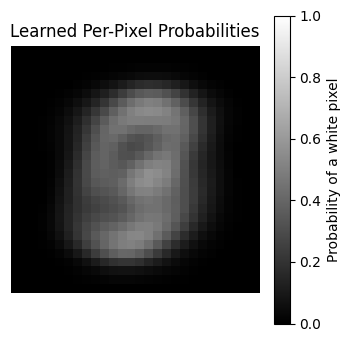

In [ ]:
# Visualize where white pixels commonly occur in the dataset.
plt.figure(figsize=(4, 4))
plt.imshow(pixel_probs, cmap="gray", vmin=0, vmax=1)
plt.colorbar(label="Probability of a white pixel")
plt.title("Learned Per-Pixel Probabilities")
plt.axis("off")
plt.show()

The probability map resembles a blurred digit because it records where white pixels frequently appear. At this stage, however, the model only contains 784 separate pixel probabilities.

## 3. Generate New Images

To generate an image, we sample every pixel independently from its learned Bernoulli distribution.

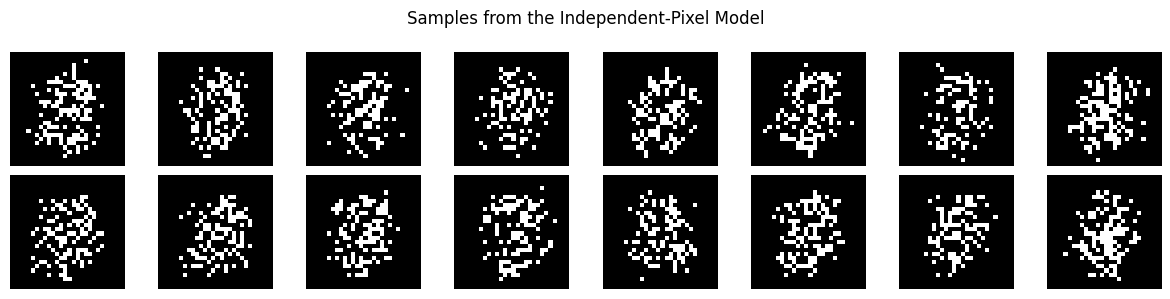

In [ ]:
# Generate each pixel independently using its learned probability.
torch.manual_seed(42)
num_samples = 16
pixel_distribution = torch.distributions.Bernoulli(probs=pixel_probs)
generated_images = pixel_distribution.sample((num_samples,))

show_images(generated_images, "Samples from the Independent-Pixel Model")

## 4. What Went Wrong?

The model learns where white pixels commonly appear, but it does not learn which pixels tend to occur together. Since each pixel is generated independently, the resulting images often lack coherent shapes and recognizable structures.

For example, the presence of a white pixel may make nearby pixels more likely to be white. Capturing these relationships requires a model of the **joint distribution** over pixels.

In today's lecture, we will introduce generative models that explicitly capture dependencies between pixels.